Baselines estimates - Part 2
------------
---------------

**Bibliography used to prepare this notebook:**
- Jonathan L. Herlocker, Joseph A. Konstan, Al Borchers, and John Riedl. 1999. An algorithmic framework for performing collaborative filtering. In Proceedings of the 22nd annual international ACM SIGIR conference on Research and development in information retrieval (SIGIR '99). Association for Computing Machinery, New York, NY, USA, 230–237. https://doi.org/10.1145/312624.312682

- Ricci, F., Rokach, L., Shapira, B. (2022). Recommender Systems Handbook, Springer.

- Yehuda Koren. 2008. Factorization meets the neighborhood: a multifaceted collaborative filtering model. In Proceedings of the 14th ACM SIGKDD international conference on Knowledge discovery and data mining (KDD '08). Association for Computing Machinery, New York, NY, USA, 426–434. https://doi.org/10.1145/1401890.1401944


Introduction
--------------

Collaborative Filtering data commonly displays significant biases. Some users consistently give higher ratings than others, and some items consistently receive higher ratings. To address these biases, it's standard practice to adjust the data by incorporating 'baseline estimates.'

The overall average rating is represented by $\mu$. A baseline estimate for an unknown rating ($r_{ui}$) is denoted by $b_{ui}$ and considers the biases of the specific user ($b_{u}$) and item ($b_{i}$):

**Equation 1:**

$$b_{ui} = \mu + b_u + b_i$$

The parameters $b_{u}$ and $b_{i}$ represent how much a particular user ('u') or item ('i') deviates from the average rating.

In order to estimate $b_{u}$ and $b_{i}$ one can solve the least squares problem:

**Equation 2:**

$$\min_{b} \sum_{(u,i) \in K} \left(r_{ui} - \mu - b_u - b_i\right)^2 + \lambda \left(\sum_u b_u^2 + \sum_i b_i^2\right)$$

Lets see how we can implement this equation in python, to analyze real data from MovieLens

In [1]:
import numpy as np
import pandas as pd

# MovieLens file path
data_path = r"C:\Users\brods\Desktop\Programacion\1-Datasets\ml-10M100K\ratings.dat"

# Load the ratings.dat file (MovieLens uses "::" as a separator)
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
ratings_df = pd.read_csv(data_path, sep="::", names=column_names, engine='python')

# Select only the columns needed for the model
ratings_df = ratings_df[['user_id', 'item_id', 'rating']]

# Ratings Dictionary {(user, item): rating}
ratings = {(row.user_id, row.item_id): row.rating for row in ratings_df.itertuples(index=False)}

# User and item sets
users = set(ratings_df['user_id'])
items = set(ratings_df['item_id'])

# General ratings average (μ in the equation)
mu = np.mean(ratings_df['rating'])

# Regularization parameter (λ in the equation)
lambda_reg = 0.02

# Learning rate for Stochastic Gradient Descent (SGD)
learning_rate = 0.005 

# Number of training iterations
epochs = 10  

# Bias initialization (b_u and b_i in the equation)
b_u = {u: 0.0 for u in users} # User bias
b_i = {i: 0.0 for i in items}  # Item bias

# Stochastic Gradient Descent (SGD) Training
# We minimize the error function:
# sum_{(u,i) ∈ K} (r_ui - μ - b_u - b_i)^2 + λ (sum_u b_u^2 + sum_i b_i^2)
# where r_ui is the actual grade and (μ + b_u + b_i) is the prediction

for epoch in range(epochs):
    total_error = 0  # Squared error accumulator
    
    for (u, i), r_ui in ratings.items():
        u, i = int(u), int(i)
        # Predicting the r_ui rating
        pred = mu + b_u[u] + b_i[i]
        
        # Error between the actual rating and the prediction
        err = r_ui - pred  #This is the (r_ui - μ - b_u - b_i) part
        
        # Updating biases b_u and b_i using SGD with regularization
        b_u[u] += learning_rate * 2 *  err - 2*(lambda_reg * b_u[u])
        b_i[i] += learning_rate * 2 *  err - 2*(lambda_reg * b_i[i])


        
        # Accumulation of squared error
        total_error += err ** 2
    rmse = np.sqrt(total_error / len(ratings))
    
    # Show average error per epoch
    print(f"Epoch {epoch + 1}/{epochs}, Error: {total_error / len(ratings):.4f}")
    print(f"Epoch {epoch + 1}/{epochs}, RMSE: {rmse:.4f}")

# Display some learned bias values
print("Example of user bias:", {k: v for k, v in list(b_u.items())[:5]})
print("Example of item bias:", {k: v for k, v in list(b_i.items())[:5]})

Epoch 1/10, Error: 0.9854
Epoch 1/10, RMSE: 0.9926
Epoch 2/10, Error: 0.9772
Epoch 2/10, RMSE: 0.9885
Epoch 3/10, Error: 0.9766
Epoch 3/10, RMSE: 0.9882
Epoch 4/10, Error: 0.9764
Epoch 4/10, RMSE: 0.9881
Epoch 5/10, Error: 0.9764
Epoch 5/10, RMSE: 0.9881
Epoch 6/10, Error: 0.9764
Epoch 6/10, RMSE: 0.9881
Epoch 7/10, Error: 0.9764
Epoch 7/10, RMSE: 0.9881
Epoch 8/10, Error: 0.9764
Epoch 8/10, RMSE: 0.9881
Epoch 9/10, Error: 0.9764
Epoch 9/10, RMSE: 0.9881
Epoch 10/10, Error: 0.9764
Epoch 10/10, RMSE: 0.9881
Example of user bias: {1: 0.30568695808264623, 2: -0.07968128922991838, 3: 0.08691129930407109, 4: 0.1301613707101446, 5: 0.09606353859129285}
Example of item bias: {1: 0.1202318317246336, 2: -0.08300685161747885, 3: -0.129301378691527, 4: -0.1284794806199353, 5: -0.13159745861187036}


Some important points to interpret the results obtained:

- total_error is useful for monitoring progress during training, but is not useful as a final evaluation metric.

- RMSE is the standard metric for evaluating recommendation models, as it is more intuitive and independent of dataset size.

The code we implemented above can also be implemented using the Surprise library, which was created to work with recommender systems. The results are almost the same.

BaselineOnly is a resource that allows us to implement the Equation (2). The 'method' parameter allows us to select ALS or SGD as optimization methods for the function.

In [2]:
import pandas as pd
from surprise import BaselineOnly, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy

# MovieLens file path
data_path = r"C:\Users\brods\Desktop\Programacion\1-Datasets\ml-10M100K\ratings.dat"

# Load the ratings.dat file (MovieLens uses "::" as a separator)
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
ratings_df = pd.read_csv(data_path, sep="::", names=column_names, engine='python')

# Select only the necessary columns
ratings_df = ratings_df[['user_id', 'item_id', 'rating']]

# Create a Reader object for Surprise
reader = Reader(line_format="user item rating", sep=",", rating_scale=(0.5, 5.0))

# Convert to Surprise format
data = Dataset.load_from_df(ratings_df, reader)

# Split into train and test sets
trainset, testset = train_test_split(data, test_size=0.2)

# Setting Up Baseline Estimates
bsl_options = {
    'method': 'als',  # Alternating Least Squares ('als') or Stochastic Gradient Descent ('sgd')
    'n_epochs': 10,   # Number of iterations
    'reg_u': 12,      # Regularization for users (ALS only)
    'reg_i': 5,       # Regularization for items (ALS only)
}

# Create the BaselineOnly model
algo = BaselineOnly(bsl_options=bsl_options)

# Train the model
algo.fit(trainset)

# Predict on the testset
predictions = algo.test(testset)

# Evaluate the model
print("RMSE:", accuracy.rmse(predictions))

Estimating biases using als...
RMSE: 0.8640
RMSE: 0.8640376449130721


Now we try with the SGD

In [20]:
bsl_options = {
    "method": "sgd",
    "learning_rate": 0.00005,
}
algo = BaselineOnly(bsl_options=bsl_options)
# Train the model
algo.fit(trainset)

# Predict on the testset
predictions = algo.test(testset)

# Evaluate the model
print("RMSE:", accuracy.rmse(predictions))

Estimating biases using sgd...
RMSE: 0.9279
RMSE: 0.9278744872713622


Using the results obtained from the calculations we performed earlier, when calculating the baseline estimates, we can begin analyzing the database.

In [3]:
print("Average user bias:", np.mean(list(b_u.values())))   
print("Average item bias:", np.mean(list(b_i.values())))    

Average user bias: 0.019958878075387303
Average item bias: -0.05860465077117118


What does average user bias (0.0199) mean?
- It is positive, but very close to 0, indicating that, on average, users tend to rate just a little higher than the global average.
- It suggests that users do not have a strong bias and tend to follow the general trend of the dataset.

What does the average item bias (-0.0586) mean?
- It is slightly negative, indicating that items tend to receive ratings slightly below the overall average.
- There may be more items with low ratings than high ratings in the dataset.
- Some items may have unfairly low ratings due to lack of information or negative user experiences.

Next, we'll try to predict how a specific user will rate a specific item. This can be useful for generating recommendations.

In [4]:
uid = str(196)  # User ID in MovieLens
iid = str(302)  # Item ID (movie)
pred = algo.predict(uid, iid)
print(f"BaselineOnly prediction for User {uid} and movie {iid}: {pred.est}")


BaselineOnly prediction for User 196 and movie 302: 3.512745556492634


Let's see how we could train our recommendation system using Equation (2) that we detailed at the beginning.

The graph bellow shows the evolution of the Root Mean Square Error (RMSE) as a function of the number of epochs for the BaselineOnly algorithm with Alternating Least Squares (ALS). 

Initially, the RMSE decreases as the model learns patterns in the data and better adjusts for user and item biases. However, after a certain number of epochs (3 or 4), the error stabilizes, indicating that the model is learning the training set rather than generalizing to new data. 

This graph is useful for determining an optimal training point, that is, the number of epochs in which the model achieves the lowest RMSE on test data without falling into overfitting. With this information, an appropriate number of iterations can be chosen to improve the accuracy of the recommender system without compromising its generalization ability.

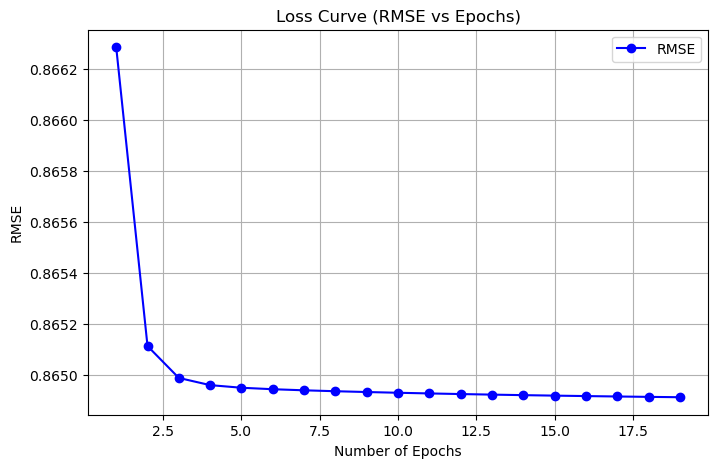

In [5]:
import matplotlib.pyplot as plt
from surprise import Dataset, BaselineOnly
from surprise.model_selection import train_test_split
from surprise import accuracy

# Load the MovieLens 100k dataset
data = Dataset.load_from_df(ratings_df, reader)

# Split into train and test
trainset, testset = train_test_split(data, test_size=0.2)

# Model parameters
n_epochs_list = list(range(1, 20))  # We will evaluate from 1 to 20 epochs
rmse_values = []  # List to store RMSE per epoch

for n_epochs in n_epochs_list:
    # Model configuration
    bsl_options = {
        'method': 'als',  # Alternating Least Squares
        'n_epochs': n_epochs,  # Number of iterations
        'reg_u': 5,  # Regularization for users
        'reg_i': 12,   # Regularization for items
    }

    # Create and train model
    algo = BaselineOnly(bsl_options=bsl_options, verbose=False)
    algo.fit(trainset)

    # Evaluate the model on a testset
    predictions = algo.test(testset)
    rmse = accuracy.rmse(predictions, verbose=False)  # Calcular RMSE
    rmse_values.append(rmse)  # Guardar RMSE

# Plot RMSE vs Epochs 
plt.figure(figsize=(8, 5))
plt.plot(n_epochs_list, rmse_values, marker='o', linestyle='-', color='b', label='RMSE')
plt.xlabel("Number of Epochs")
plt.ylabel("RMSE")
plt.title("Loss Curve (RMSE vs Epochs)")
plt.legend()
plt.grid()
plt.show()


Baselines estimates and Similarity measures
---------
-----------

Baseline estimates can be improved by using tools such as similarity measures.

The similarity measures play a double role in neighborhood-based recommendation methods: 
- (1) they allow to select trusted neighbors whose ratings are used in the prediction, and 
- (2) they provide the means to give more or less importance to these neighbors in the prediction. 

The computation of the similarity weights is one of the most critical aspects of building a neighborhood-based recommender system, as it can have a significant impact on both its accuracy and its performance.

Apopular measure that compares ratings where the effects of mean and variance have been removed is the Pearson Correlation (PC) similarity:

$$
PC(u,v) = \frac{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_u})(r_{vi} - \bar{r_v})}{\sqrt{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_u})^2 \sum_{i \in I(u;v)} ((r_{vi} - \bar{r_v})^2}} 
$$

The same idea can beused to obtain similarities between two items i and j,this time by comparing the ratings made by users that have rated both these items:

$$
PC(i,j) = \frac{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_i})(r_{uj} - \bar{r_j})}{\sqrt{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_i})^2 \sum_{i \in I(u;v)} ((r_{uj} - \bar{r_j})^2}} 
$$

The differences in the rating scales of individual users are often more pronounced than the differences in ratings given to individual items. Therefore, while computing the item similarities, it may bemore appropriate to compare ratings that are centered on their user mean, instead of their item mean. The Adjusted Cosine(AC) similarity, is a modification of the PC item similarity which compares user mean-centered ratings:

$$
AC(i,j) = \frac{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_u})(r_{uj} - \bar{r_u})}{\sqrt{\sum_{i \in I(u;v)} (r_{ui} - \bar{r_u})^2 \sum_{i \in I(u;v)} ((r_{uj} - \bar{r_u})^2}} 
$$

The key difference between Pearson's correlation coefficient (PC) and adjusted cosine similarity (AC) lies in how they handle data normalization, especially when comparing items rather than users.
- The PC, in the user-user version, compares the ratings that two users have made on the same items, centering the values on the average of each user.
- The PC, in the item-item version, does the same but centered on the mean of each item
- Adjusted Cosine Similarity (AC) is used only for item-item comparisons and adjusts ratings by subtracting the user mean rather than the item mean.

The motivation behind AC is that users may have different rating scales (some may use only 4-5 stars, while others use the entire 1-5 range), so it is more consistent to center ratings on the user average.

Unlike Pearson (in the item-item version), which focuses on the item mean $\bar{r_i}$, here it focuses on the user mean $\bar{r_u}$.

\begin{array}{|c|c|c|}
\hline
\textbf{Measure} & \textbf{Normalization in user-user comparison} & \textbf{Normalization in item-item comparison} \\
\hline
\text{Pearson (PC)} & \textbf{Centered on the user average} & \textbf{Centered on the item average} \\
\hline
\text{Adjusted Cosine (AC)} & \textbf{Not applicable} & \textbf{Centered on the user average} \\
\hline
\end{array}

Let's see an example of how we could implement these three similarity measures. The first step we will take is to load the information from our database so we can work with it.


In [6]:
import pandas as pd
import numpy as np
from surprise import Reader, Dataset

# MovieLens file path
data_path = r"C:\Users\brods\Desktop\Programacion\1-Datasets\ml-10M100K\ratings.dat"

# Load the ratings.dat file (MovieLens uses "::" as a separator)
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
ratings_df = pd.read_csv(data_path, sep="::", names=column_names, engine='python')

# Select only the necessary columns
ratings_df = ratings_df[['user_id', 'item_id', 'rating']]

# Create a Reader object for Surprise
reader = Reader(line_format="user item rating", sep="::", rating_scale=(0.5, 5.0))

# Convert to Surprise format
data = Dataset.load_from_df(ratings_df, reader)

Once we have the information available, we perform the following steps:
- We select an item at random
- We see which items have received the highest ratings from users and other items in the database.
- We sort the data in descending order. Our goal is to measure the similarity between the target item and another item where many users have seen both movies.

In [7]:
def items_with_most_common_users(df, target_item):
    # Filter users who have rated the target item
    users_who_rated_target = df[df['item_id'] == target_item]['user_id'].unique()
    
    # Filter the ratings of users who have rated the target item
    common_users_ratings = df[df['user_id'].isin(users_who_rated_target)]
    
    # Count how many users have rated each item in conjunction with the target item
    item_counts = common_users_ratings.groupby('item_id')['user_id'].nunique()
    
   # Remove the target item from the item list
    item_counts = item_counts.drop(target_item, errors='ignore')
    
    # Get the 10 items with the most users in common
    top_items = item_counts.sort_values(ascending=False).head(10)
    
    return top_items

# Call the function to get the 10 items with the most users in common with item 357
top_items = items_with_most_common_users(ratings_df, 357)

# Show the 10 items with the most users in common with item 357
print(f"The 10 items with the most users in common with item 357 are:")
print(top_items)


The 10 items with the most users in common with item 357 are:
item_id
356    13836
296    12458
480    12439
593    11989
457    11597
597    11249
377    11124
590    10934
589    10867
318    10777
Name: user_id, dtype: int64


We have the 10 items with the most users in common with the target item.

We will then move on to defining our similarity functions, according to the theory.

In [8]:
def pearson_correlation_user(df, user1, user2):
    common_items = df[df['user_id'].isin([user1, user2])].pivot(index='item_id', columns='user_id', values='rating').dropna()
    
    if common_items.empty:
        return 0  # There are no items in common
    
    r_u = common_items[user1].mean()
    r_v = common_items[user2].mean()
    
    numerator = np.sum((common_items[user1] - r_u) * (common_items[user2] - r_v))
    denominator = np.sqrt(np.sum((common_items[user1] - r_u) ** 2) * np.sum((common_items[user2] - r_v) ** 2))
    
    return numerator / denominator if denominator != 0 else 0

def pearson_correlation_item(df, item1, item2):
    common_users = df[df['item_id'].isin([item1, item2])].pivot(index='user_id', columns='item_id', values='rating').dropna()
    
    if common_users.empty:
        return 0,0  # There are no users in common
    
    r_i = common_users[item1].mean()
    r_j = common_users[item2].mean()
    
    numerator = np.sum((common_users[item1] - r_i) * (common_users[item2] - r_j))
    denominator = np.sqrt(np.sum((common_users[item1] - r_i) ** 2) * np.sum((common_users[item2] - r_j) ** 2))
    
    return numerator / denominator if denominator != 0 else 0, len(common_users)

def adjusted_cosine_similarity(df, item1, item2):
    common_users = df[df['item_id'].isin([item1, item2])].pivot(index='user_id', columns='item_id', values='rating').dropna()
    
    if common_users.empty:
        return 0,0  # There are no users in common
    
    user_means = df.groupby('user_id')['rating'].mean()
    
    numerator = np.sum((common_users[item1] - user_means) * (common_users[item2] - user_means))
    denominator = np.sqrt(np.sum((common_users[item1] - user_means) ** 2) * np.sum((common_users[item2] - user_means) ** 2))
    
    return numerator / denominator if denominator != 0 else 0, len(common_users)

Let's do a test between two items and see how many users have rated both movies.

In [9]:
item1, item2 = 357, 356
similarity1 = pearson_correlation_item(ratings_df, item1, item2)
similarity2 = adjusted_cosine_similarity(ratings_df, item1, item2)
print(f"Pearson similarity between item {item1} and item {item2}: {similarity1}")
print(f"Adjusted cosine similarity between item {item1} and item {item2}: {similarity2}")

Pearson similarity between item 357 and item 356: (0.1439932288520264, 13836)
Adjusted cosine similarity between item 357 and item 356: (0.08254141747687738, 13836)


Despite having a large number of users in common, there doesn't seem to be a strong relationship between the two films.

Let's temporarily change our approach to the problem. Let's simply look for the items most similar to the target item.

In [10]:
def top_n_similar_items(df, target_item, n=5):
    # Get all unique items except the target
    unique_items = df['item_id'].unique()
    unique_items = unique_items[unique_items != target_item]  # Exclude the target article
    
    similarities = []

    for item in unique_items:
        similarity, common_users = pearson_correlation_item(df, target_item, item)
        if common_users > 5:  # Only consider items with common users
            similarities.append((item, similarity, common_users))

    # Sort by Pearson similarity in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Get the N most similar items
    top_items = similarities[:n]

    return top_items

# Find the 5 items most similar to item 357
top_similar_items = top_n_similar_items(ratings_df, 357, n=5)

# Mostrar resultados
print("The 5 items most similar to item 357 are:")
for item, similarity, common_users in top_similar_items:
    print(f"Item {item}: Similarity {similarity:.4f}, Common users {common_users}")


The 5 items most similar to item 357 are:
Item 32158: Similarity 0.9585, Common users 6
Item 7277: Similarity 0.9220, Common users 6
Item 60133: Similarity 0.8918, Common users 7
Item 25762: Similarity 0.8864, Common users 10
Item 31040: Similarity 0.8771, Common users 6


It's interesting to note that the number of users two items have in common has a strong impact on the similarity measure's results.

To mitigate these types of problems, in the following section, we'll look at how we can introduce some resources that will help us give each similarity measure the right weight.

The importance of Weights for similarity meassures implementation
-------------------
-------------------


Central to most item-oriented approaches is a similarity measure between items. Frequently, it is based on the Pearson correlation coefficient, $ρ_{ij}$, which measures the tendency of users to rate items $i$ and $j$ similarly. Since many ratings are unknown, it is expected that some items share only a handful of common raters. Computation of the correlation coefficient is based only on the common user support. Accordingly, similarities based on a greater user support are more reliable. An appropriate similarity measure, denoted by $s_{ij}$, would be a shrunk correlation coefficient:

**Equation 3:**

$$s_{ij} = \frac{n_{ij}}{n_{ij} + \lambda} \rho_{ij}$$

The variable *$n_{ij}$* denotes the number of users that rated both **i** and **j**. A typical value for **λ** is 100. The symbol *$ρ_{ij}$* is the similarity measure selected by the investigator, like the Pearson correlation coefficient. We already know that literature suggests other alternatives for a similarity measure. But lets take as an example the Pearson correlation coefficient, defined as:

$$
\rho = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2 \sum_{i=1}^{n} (Y_i - \bar{Y})^2}} 
$$

Our goal is to predict $r_{ui}$, the unobserved rating by user $u$ for item $i$. Using the similarity measure *$\rho$*, we identify the $k$ items rated by $u$, which are most similar to $i$. This set of $k$ neighbors is denoted by $S^k(i;u)$. The predicted value of $r_{ui}$ is taken as a weighted average of the ratings of neighboring items, while adjusting for user and item effects through the baseline estimates:

**Equation 4:**

$$r_{ui} = b_{ui} + \frac{\sum_{j \in S^k(i;u)} s_{ij} (r_{uj} - b_{uj})}{\sum_{j \in S^k(i;u)} s_{ij}}$$



Example
----------
----------
Suppose we want to predict a user's rating for an item $i$, and we have two neighboring items $j_1$ and $j_2$ that the user has already rated. The following table shows the actual ratings, base estimates, and deviations:

$$
\begin{array}{|c|c|c|c|c|}
\hline
\text{Item} & r_{uj} & b_{uj} & r_{uj} - b_{uj} & s_{ij} \\
\hline
j_1 & 4.5 & 4.0 & 0.5 & 0.8 \\
j_2 & 3.0 & 3.5 & -0.5 & 0.2 \\
\hline
\end{array}
$$

The fraction in equation 4 is calculated as:

$$
\frac{\sum_{j \in S^k(i;u)} s_{ij} (r_{uj} - b_{uj})}{\sum_{j \in S^k(i;u)} s_{ij}}
= \frac{(0.8 \times 0.5) + (0.2 \times -0.5)}{0.8 + 0.2}
$$

$$
= \frac{0.4 - 0.1}{1.0} = 0.3
$$

This value of 0.3 is added to the $b_{ui}$ term in equation 4 to obtain the final prediction of $r_{ui}$.

Some remarks on classical neighborhood-based recommendation methods
------------
------------

Neighborhood-based methods of this form became very popular because they are intuitive and relatively simple to implement:
- They are intuitive: They are based on the natural idea that if a user liked items similar to i, then they will probably also like i.
- SThey are easy to implement: They do not require complex models, just a similarity metric and an interpolation mechanism.

However, there are some points we should keep in mind about this type of strategy.
- Lack of a formal model to justify them: unlike matrix factorization methods, neighbor-based methods do not emerge from a solid mathematical formulation. They rely on heuristics, which means that their performance can be inconsistent.
- The equation uses $s_{ij}$ (similarity between i and j), usually based on the Pearson correlation. This measure evaluates each pair of items independently, ignoring how they relate to the rest of the set of neighbors. If three movies A, B, C are similar to each other, but the correlation between A and B is weak because few users rated them together, the model has no way of capturing the overall structure.